In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('data.csv')
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

In [4]:
split1 = int(0.6 * len(X))
split2 = int(0.8 * len(X))

X_train, y_train = X[:split1], y[:split1]
X_val,   y_val   = X[split1:split2], y[split1:split2]
X_test,  y_test  = X[split2:], y[split2:]

In [5]:
# KNN is distance-based — scaling is mandatory
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [22]:
from sklearn.metrics import recall_score

best_k    = 1
best_recall = 0

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    rec = recall_score(y_val, knn.predict(X_val))
    print(f"K={k:>2}  |  Recall = {rec*100:.2f}%")
    if rec > best_recall:
        best_recall = rec
        best_k      = k
print (best_k)

K= 1  |  Recall = 96.55%
K= 2  |  Recall = 93.10%
K= 3  |  Recall = 96.55%
K= 4  |  Recall = 96.55%
K= 5  |  Recall = 96.55%
K= 6  |  Recall = 96.55%
K= 7  |  Recall = 96.55%
K= 8  |  Recall = 96.55%
K= 9  |  Recall = 96.55%
K=10  |  Recall = 96.55%
K=11  |  Recall = 100.00%
K=12  |  Recall = 96.55%
K=13  |  Recall = 100.00%
K=14  |  Recall = 100.00%
K=15  |  Recall = 100.00%
K=16  |  Recall = 100.00%
K=17  |  Recall = 100.00%
K=18  |  Recall = 100.00%
K=19  |  Recall = 100.00%
K=20  |  Recall = 96.55%
K=21  |  Recall = 100.00%
K=22  |  Recall = 96.55%
K=23  |  Recall = 96.55%
K=24  |  Recall = 96.55%
K=25  |  Recall = 96.55%
K=26  |  Recall = 96.55%
K=27  |  Recall = 96.55%
K=28  |  Recall = 96.55%
K=29  |  Recall = 96.55%
K=30  |  Recall = 96.55%
11


In [23]:
# Retrain on train+val with best K, evaluate on test
X_full = np.concatenate([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_full, y_full)

p_test = knn.predict(X_test)

print(f"Train Accuracy : {accuracy_score(y_full, knn.predict(X_full))*100:.2f}%")
print(f"Test  Accuracy : {accuracy_score(y_test, p_test)*100:.2f}%")

Train Accuracy : 97.14%
Test  Accuracy : 98.25%


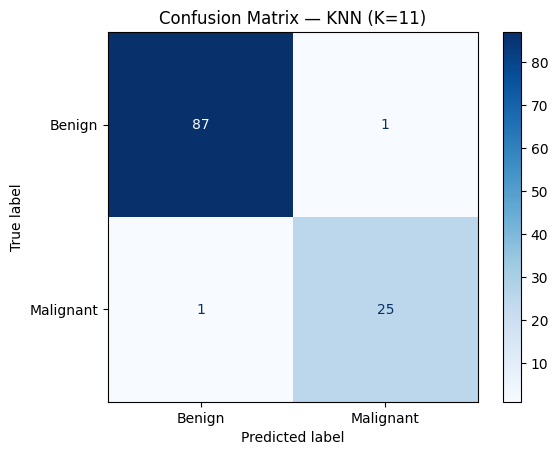

In [24]:
cm   = confusion_matrix(y_test, p_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — KNN (K={best_k})')
plt.show()

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"Precision : {precision_score(y_test, p_test)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, p_test)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, p_test)*100:.2f}%")
print(f"\nConfusion Matrix:")
print(cm)
print(f"Best K = {best_k}")

Precision : 96.15%
Recall    : 96.15%
F1 Score  : 96.15%

Confusion Matrix:
[[87  1]
 [ 1 25]]
Best K = 11
